In [7]:
import os
from openimages.download import download_dataset

In [8]:
data_dir = 'data'
number_of_samples = 350
classes = ['Missile', 'Balloon', 'Castle']

In [9]:
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

In [10]:
if not (os.path.exists(os.path.join(data_dir, classes[0].lower())) and
        os.path.exists(os.path.join(data_dir, classes[1].lower())) and
        os.path.exists(os.path.join(data_dir, classes[2].lower()))):
    download_dataset(data_dir, classes, limit=number_of_samples)

In [11]:
import torch
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import numpy as np
from skimage import io
from skimage.transform import resize
from skimage.color import gray2rgb
import glob

In [12]:
def read_img(file_name):
    img = io.imread(file_name)
    if img.ndim == 2:
        img = gray2rgb(img)
    img = resize(img, (224, 224))
    img = torch.tensor(img)
    img = img.permute(2, 0, 1)
    return img.float()

In [13]:
class CustomDataset(Dataset):
    def __init__(self, images_dir):
        self.images_dir = images_dir
        self.transforms = transforms

        self.class1_files = glob.glob(self.images_dir + '/{}/images/*.jpg'.format(classes[0].lower()))
        self.class2_files = glob.glob(self.images_dir + '/{}/images/*.jpg'.format(classes[1].lower()))
        self.class3_files = glob.glob(self.images_dir + '/{}/images/*.jpg'.format(classes[2].lower()))
        self.class1_len = len(self.class1_files)
        self.class2_len = len(self.class2_files)
        self.class3_len = len(self.class3_files)

        self.files = self.class1_files + self.class2_files + self.class3_files

        self.labels = np.zeros(len(self.files))
        self.labels[self.class1_len:self.class1_len + self.class2_len] = 1
        self.labels[self.class1_len + self.class2_len:] = 2

        self.order = [x for x in np.random.permutation(len(self.labels))]
        self.files = [self.files[x] for x in self.order]
        self.labels = [self.labels[x] for x in self.order]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        file = self.files[i]
        im = read_img(file)

        img = im.clone().detach()

        y = self.labels[i]
        return img, y

In [14]:
dataset = CustomDataset(data_dir)
train_dataset = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=4, prefetch_factor=2)
iterator = iter(train_dataset)

In [15]:
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model.eval()
pass

In [16]:
class_indices = []
for cls in classes:
    idx = weights.meta['categories'].index(cls.lower())
    class_indices.append(idx)

In [17]:
def prepare_batch(images):
    batch = []
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    for img in images:
        batch.append((img - mean) / std)

    return torch.cat(batch, dim=0)

In [18]:
tp = [0, 0, 0]
fp = [0, 0, 0]
tn = [0, 0, 0]
fn = [0, 0, 0]

all_scores = []
all_labels = []

with torch.no_grad():
    for images, labels in iterator:
        batch = prepare_batch(images)
        predictions = model(batch).softmax(1)

        all_scores.append(predictions[:, class_indices])
        all_labels.append(labels)

all_scores = torch.cat(all_scores).numpy()
all_labels = torch.cat(all_labels).numpy()

In [25]:
tp = np.zeros((100, 3))
fp = np.zeros((100, 3))
tn = np.zeros((100, 3))
fn = np.zeros((100, 3))

thresholds = np.arange(start=0.01, stop=1.01, step=0.01)

threshold = 0.09
for i, threshold in enumerate(thresholds):
    for c in range(3):
        predicted_positive = all_scores[:, c] >= threshold
        actual_positive = all_labels == c

        tp[i, c] = (predicted_positive & actual_positive).sum()
        fp[i, c] = (predicted_positive & ~actual_positive).sum()
        tn[i, c] = (~predicted_positive & ~actual_positive).sum()
        fn[i, c] = (~predicted_positive & actual_positive).sum()

accuracy = (tp + tn) / (tp + fp + tn + fn)
precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) != 0)
recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) != 0)
f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) != 0)

print()
print('Classes: ', classes)
print('Mean accuracy: ', accuracy.mean(1) * 100)
print('Mean precision: ', precision.mean(1) * 100)
print('Mean recall: ', recall.mean(1) * 100)
print('Mean F1: ', f1.mean(1) * 100)



Classes:  ['Missile', 'Balloon', 'Castle']
Mean accuracy:  [97.21351445 95.47196099 94.63601533 93.80006966 93.10344828 92.44165796
 92.0585162  91.57088123 90.97875305 90.42145594 90.00348311 89.62034134
 89.13270637 88.92371996 88.50574713 88.15743643 87.70463253 87.42598398
 87.00801115 86.13723441 85.37095089 84.56983629 84.01253918 83.49007315
 82.75862069 82.16649251 81.50470219 80.94740509 80.52943225 80.11145942
 79.41483804 78.892372   78.19575061 77.6384535  76.83733891 76.41936607
 76.00139324 75.65308255 75.13061651 74.81713689 74.25983978 73.73737374
 73.35423197 73.07558342 72.72727273 72.20480669 71.92615813 71.54301637
 71.12504354 70.81156392 70.6025775  70.28909788 69.97561825 69.55764542
 69.348659   69.13967259 68.96551724 68.75653083 68.47788227 68.37338906
 68.23406479 68.02507837 67.88575409 67.74642982 67.57227447 67.46778126
 67.39811912 67.32845698 67.18913271 67.11947057 67.11947057 67.0846395
 66.98014629 66.98014629 66.84082201 66.80599094 66.80599094 66.8

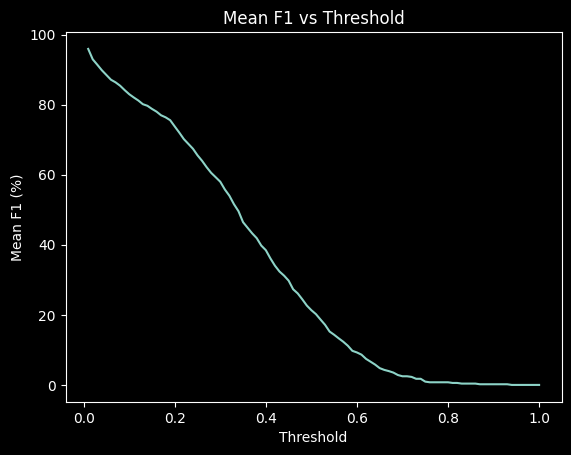

Best threshold: 0.01, Mean F1: 95.89%


In [24]:
import matplotlib.pyplot as plt

mean_f1 = f1.mean(axis=1) * 100

plt.plot(thresholds, mean_f1)
plt.xlabel('Threshold')
plt.ylabel('Mean F1 (%)')
plt.title('Mean F1 vs Threshold')
plt.show()

best_idx = mean_f1.argmax()
print(f'Best threshold: {thresholds[best_idx]:.2f}, Mean F1: {mean_f1[best_idx]:.2f}%')

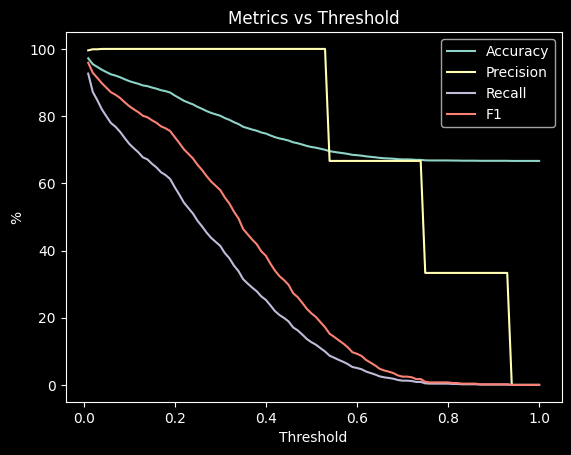

In [28]:
plt.title('Metrics vs Threshold')

plt.plot(thresholds, accuracy.mean(axis=1) * 100, label='Accuracy')
plt.plot(thresholds, precision.mean(axis=1) * 100, label='Precision')
plt.plot(thresholds, recall.mean(axis=1) * 100, label='Recall')
plt.plot(thresholds, f1.mean(axis=1) * 100, label='F1')

plt.xlabel('Threshold')
plt.ylabel('%')

plt.legend()
plt.show()